# Week 3 — Block 2: Guided Demo (Tabular & Multivariate)

**DATS 6401 · Visualization of Complex Data**

~30 min on the wine dataset (178 wines × 13 chemistry columns, 3 cultivars):

1. Wrangle: reshape · group · merge (~8 min)
2. Correlation heatmap → verify with a scatter (~8 min)
3. Standardize → PCA → explained variance → loadings (~14 min)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

wine = load_wine(as_frame=True)
df = wine.data.copy()
df["cultivar"] = wine.target
print(df.shape)
df.head(3)

(178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0


## Part 1 — The wrangling verbs, live

In [4]:
# groupby: one row per cultivar (the aggregation level changes the chart!)
by_cultivar = df.groupby("cultivar")[["alcohol", "flavanoids", "color_intensity"]].mean()
by_cultivar

,alcohol,flavanoids,color_intensity
cultivar,,,
0,13.744746,2.982373,5.528305
1,12.278732,2.080845,3.086620
2,13.153750,0.781458,7.396250


In [5]:
# melt: wide -> long, so 'measurement' becomes a variable we can facet/encode on
long = by_cultivar.reset_index().melt(id_vars="cultivar",
                                      var_name="measurement", value_name="mean_value")
long.head(6)

,cultivar,measurement,mean_value
0,0,alcohol,13.744746
1,1,alcohol,12.278732
2,2,alcohol,13.153750
3,0,flavanoids,2.982373
4,1,flavanoids,2.080845
5,2,flavanoids,0.781458


In [6]:
# merge: attach external info (here: a tiny lookup we invent live)
labels = pd.DataFrame({"cultivar": [0, 1, 2], "label": ["Barolo", "Grignolino", "Barbera"]})
long = long.merge(labels, on="cultivar")
long.head(3)

,cultivar,measurement,mean_value,label
0,0,alcohol,13.744746,Barolo
1,1,alcohol,12.278732,Grignolino
2,2,alcohol,13.153750,Barbera


**Narrate:** three verbs, ten seconds each — and now the data can answer grouped questions. The melt step is the one students forget exists; show the shape change explicitly.

## Part 2 — Correlation: map, then verify

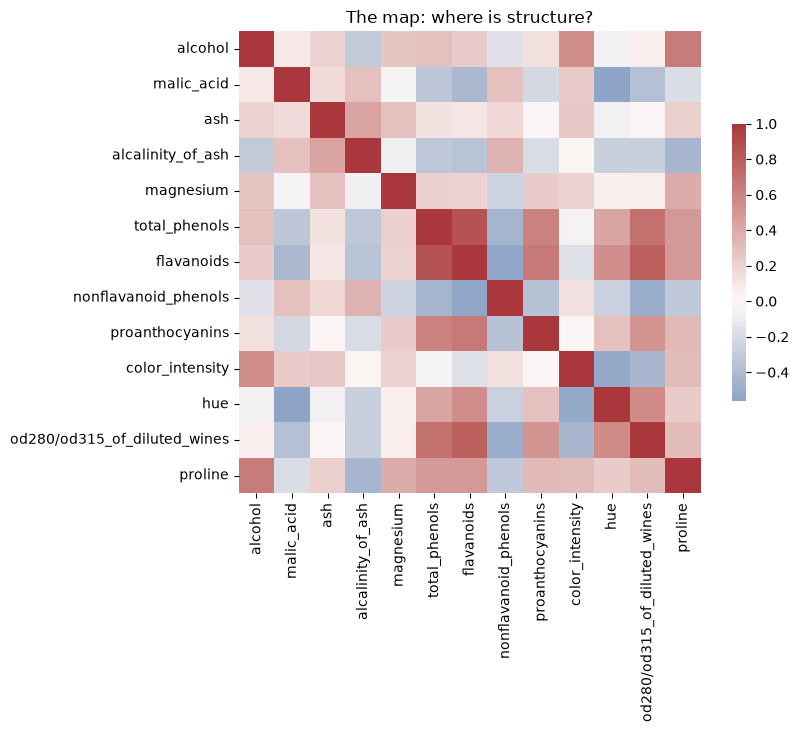

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(wine.data.corr(), cmap="vlag", center=0, square=True,
            cbar_kws={"shrink": 0.6}, ax=ax)
ax.set_title("The map: where is structure?")
plt.show()

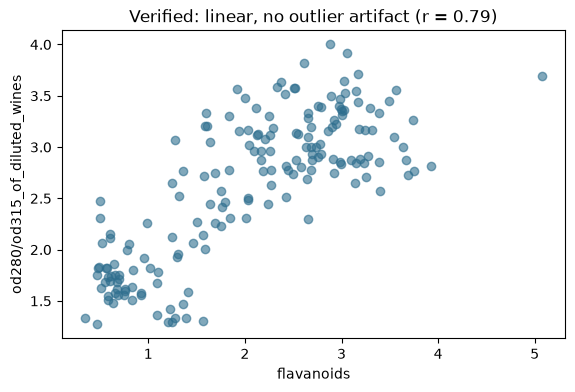

In [8]:
# The heatmap says flavanoids & od280... correlate strongly. VERIFY — never report unseen r:
pair = ("flavanoids", "od280/od315_of_diluted_wines")
r = wine.data[list(pair)].corr().iloc[0, 1]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(wine.data[pair[0]], wine.data[pair[1]], alpha=0.6, color="#2E6E8E")
ax.set_xlabel(pair[0]); ax.set_ylabel(pair[1])
ax.set_title(f"Verified: linear, no outlier artifact (r = {r:.2f})")
plt.show()

## Part 3 — PCA, the honest way

Three beats: **standardize** (or proline's units hijack PC1) → **project** (print explained variance ON the axes) → **interpret** (loadings turn 'PC1' into a sentence).

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = StandardScaler().fit_transform(wine.data)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)
print("explained variance:", pca.explained_variance_ratio_.round(3))

explained variance: [0.362 0.192]


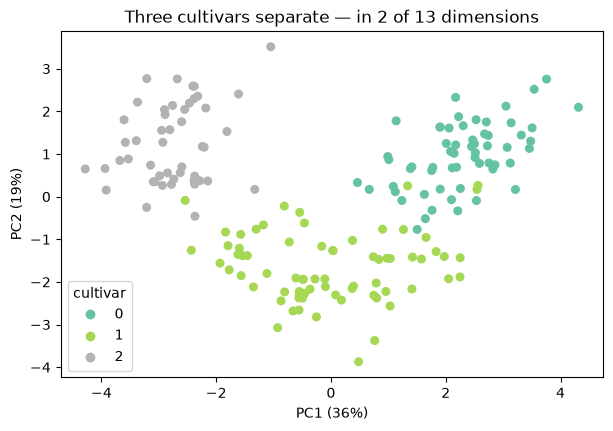

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=wine.target, cmap="Set2", s=30)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.set_title("Three cultivars separate — in 2 of 13 dimensions")
ax.legend(*sc.legend_elements(), title="cultivar")
plt.show()

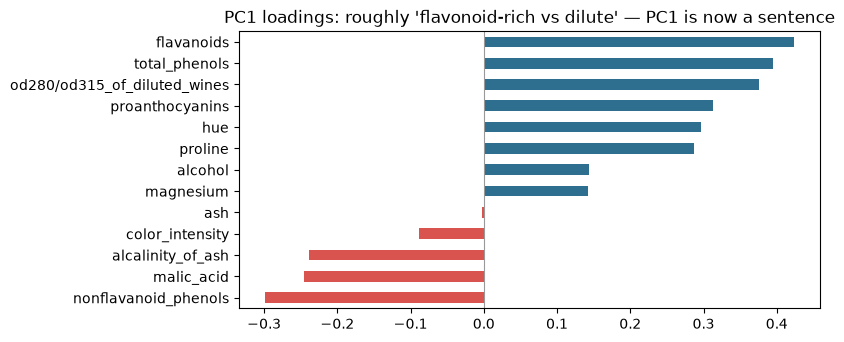

In [11]:
loadings = pd.Series(pca.components_[0], index=wine.data.columns).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 3.6))
loadings.plot.barh(ax=ax, color=np.where(loadings > 0, "#2E6E8E", "#d9534f"))
ax.axvline(0, color="#999", lw=0.8)
ax.set_title("PC1 loadings: roughly 'flavonoid-rich vs dilute' — PC1 is now a sentence")
plt.show()

**Demonstrate the failure mode** (30 seconds): rerun PCA on raw `wine.data.values` without the scaler — watch the cultivar separation collapse and PC1 become 'the proline axis'. Cheap demo, permanent lesson.

## Wrap-up → Block 3

Pipeline: **wrangle → heatmap → verify → standardize → project → interpret.** Block 3 runs it on a dataset of your choice, then wraps it in an app.